# Create Survival Prediction Model using PyTorch

One strategy would be to replicate the [DeepSurv model](https://arxiv.org/abs/1606.00931), which is a deep neural network for survival analysis, essentially a nonlinear version of the Cox proportional hazard model. 

DeepSurv takes a list of features, and learns a risk function from input features. 
No restrictions, all types of data: clinical, gene expression, genetic mutations, are all treated the same. 

## Multi-modal Learning Model

Our data includes 3 unique modalities: 
- Clinical metadata
- Z-scored Gene Expression 
- Genetic Mutation data

So we will create separate encoders for each modality

Clinical features ──► Clinical MLP    ┐

Expression matrix ──► Expr Encoder ├─► Fusion ─► Risk score ─► Cox loss

Mutation matrix ────► Mut Encoder ─┘

## Architecture
1. Clinical Encoder (MLP): Low depth, minimal regularization
2. Gene Expression Encoder (Autoencoder or Bottleneck MLP)
Options: 
- Variance Filtered Genes
- Pathway Scores
- Autoencoder Latent Space
3. Mutational Autoencoder
- Binary gene-level mutation matrix
- Tumor mutational burden

## Training strategy 

1. Train clinical-only DeepSurv model
2. Add expression autoencoder (similar to Cox model) 
3. Add mutation autoencoder 
4. Fine-tune all layers

## Evaluation Strategies
Stratify patients by predicted risk tertiles

Plot Kaplan Meier curves

Compare against one another:

CoxPH (clinical)

CoxPH (clinical + expression)

DeepSurv multimodal

In [1]:
# load libraries
import pandas as pd
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader

import pyhere as here
from sklearn.preprocessing import StandardScaler


### Load Data

In [2]:
### Load data 

# load clinical metadata
clinical = pd.read_csv(here.here("data", "processed","clinical_data.csv"))
# load expression data
expression_data = pd.read_csv(here.here("data", "processed","expression_data.csv"))
# mutation binary data
mutation_binary = pd.read_csv(here.here("data", "processed","mutation_binary_data.csv"))
# mutation classified data
mutation_classified = pd.read_csv(here.here("data", "processed","mutation_classified_data.csv"))

# Example of Multi-modal Learning Model

Mockup of what the final model will look like, with toy data

### Loss Function

In [3]:
# partial likelihood loss function for Cox Proportional Hazards model
def cox_ph_loss(risk_scores, times, events):
    """
    Negative partial log-likelihood for Cox PH
    """
    order = torch.argsort(times, descending=True)
    risk_scores = risk_scores[order]
    events = events[order]

    log_cumsum = torch.logcumsumexp(risk_scores, dim=0)
    loss = -torch.sum((risk_scores - log_cumsum) * events)
    return loss / events.sum()

### Modality-specific Encoders

In [4]:
import torch.nn as nn

# clinical data encoder
class ClinicalEncoder(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.ReLU()
        )

    def forward(self, x):
        return self.net(x)

In [5]:
# Expression data encoder
class ExpressionEncoder(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(512, 128),
            nn.ReLU()
        )

    def forward(self, x):
        return self.net(x)

In [6]:
# Mutation data encoder
class MutationEncoder(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU()
        )

    def forward(self, x):
        return self.net(x)

### Multimodal DeepServ Model

In [7]:
# Multi-modal DeepSurv model, combining clinical, expression, and mutation data
class MultiModalDeepSurv(nn.Module):
    def __init__(self, clin_dim, expr_dim, mut_dim):
        super().__init__()

        self.clin_enc = ClinicalEncoder(clin_dim)
        self.expr_enc = ExpressionEncoder(expr_dim)
        self.mut_enc  = MutationEncoder(mut_dim)

        self.head = nn.Sequential(
            nn.Linear(32 + 128 + 64, 64),
            nn.ReLU(),
            nn.Dropout(0.3), # regularization, prevents overfitting by setting 30% of neurons to zero during training
            nn.Linear(64, 1)
        )

    def forward(self, x_clin, x_expr, x_mut):
        z_clin = self.clin_enc(x_clin)
        z_expr = self.expr_enc(x_expr)
        z_mut  = self.mut_enc(x_mut)

        z = torch.cat([z_clin, z_expr, z_mut], dim=1)
        return self.head(z).squeeze(-1)


# Training function for one epoch
def train_epoch(model, optimizer, x_clin, x_expr, x_mut, time, event):
    model.train()
    optimizer.zero_grad()

    risk = model(x_clin, x_expr, x_mut)
    loss = cox_ph_loss(risk, time, event)

    loss.backward()
    optimizer.step()
    return loss.item()


### Example run with randomized data

In [8]:
# example run with randomized data
N = 1500  # number of samples
C = 30      # clinical
G = 1000   # expression
M = 200    # mutation

x_clin = torch.randn(N, C)
x_expr = torch.randn(N, G)
x_mut  = torch.randint(0, 2, (N, M)).float()

time  = torch.rand(N) * 100
event = torch.randint(0, 2, (N,)).float()

model = MultiModalDeepSurv(C, G, M)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

for epoch in range(50):
    loss = train_epoch(
        model,
        optimizer,
        x_clin,
        x_expr,
        x_mut,
        time,
        event
    )
    if epoch % 10 == 0:
        print(f"Epoch {epoch} | Loss: {loss:.4f}")


Epoch 0 | Loss: 6.3197
Epoch 10 | Loss: 5.7489
Epoch 20 | Loss: 4.6974
Epoch 30 | Loss: 4.5673
Epoch 40 | Loss: 4.4497


### Evaluation (C-index)

In [9]:
from lifelines.utils import concordance_index

model.eval()
with torch.no_grad():
    risk = model(x_clin, x_expr, x_mut).numpy()

c_index = concordance_index(
    time.numpy(),
    -risk,
    event.numpy()
)

print("C-index:", c_index)


C-index: 0.9808441495739926


Remarkably good C-index! (Almost like the data isn't real! )

Next, we will train the model in increments, beginning with the clinical encoder only.

# Clinical-only Model

To begin, we will train a neural Cox model using only clinical variables, similar to the original Cox Hazard model. 

Once we have an effective model using only clinical features, we can expand it to clinical + gene expression, and finally, clinical, gene expression, and mutation data. 

## Clinical DeepSurv model class
This is a single neural network with a sequence of:
- Linear layer (input -> 32 dim)
- ReLu
- 20% dropout normalization
- Final linear layer (32 dim -> risk score)

### First: Encode clinical data for use with PyTorch

Clinical data includes categorical/ string based data, while PyTorch expects data as tensors. 

We will one-hot encode categorical data. 

In [10]:
import pandas as pd
pd.set_option('display.max_columns', None)

# overview of our clinical data
clinical.head()

,patient_id,age_at_diagnosis,type_of_breast_surgery,cancer_type,cancer_type_detailed,cellularity,chemotherapy,pam50_+_claudin-low_subtype,cohort,er_status_measured_by_ihc,er_status,neoplasm_histologic_grade,her2_status_measured_by_snp6,her2_status,tumor_other_histologic_subtype,hormone_therapy,inferred_menopausal_state,integrative_cluster,primary_tumor_laterality,lymph_nodes_examined_positive,mutation_count,nottingham_prognostic_index,oncotree_code,overall_survival_months,overall_survival,pr_status,radio_therapy,3-gene_classifier_subtype,tumor_size,tumor_stage,death_from_cancer
0,0,75.65,MASTECTOMY,Breast Cancer,Breast Invasive Ductal Carcinoma,NaN,0,claudin-low,1.0,Positve,Positive,3.0,NEUTRAL,Negative,Ductal/NST,1,Post,4ER+,Right,10.0,NaN,6.044,IDC,140.500000,1,Negative,1,ER-/HER2-,22.0,2.0,Living
1,2,43.19,BREAST CONSERVING,Breast Cancer,Breast Invasive Ductal Carcinoma,High,0,LumA,1.0,Positve,Positive,3.0,NEUTRAL,Negative,Ductal/NST,1,Pre,4ER+,Right,0.0,2.0,4.020,IDC,84.633333,1,Positive,1,ER+/HER2- High Prolif,10.0,1.0,Living
2,5,48.87,MASTECTOMY,Breast Cancer,Breast Invasive Ductal Carcinoma,High,1,LumB,1.0,Positve,Positive,2.0,NEUTRAL,Negative,Ductal/NST,1,Pre,3,Right,1.0,2.0,4.030,IDC,163.700000,0,Positive,0,unknown,15.0,2.0,Died of Disease
3,6,47.68,MASTECTOMY,Breast Cancer,Breast Mixed Ductal and Lobular Carcinoma,Moderate,1,LumB,1.0,Positve,Positive,2.0,NEUTRAL,Negative,Mixed,1,Pre,9,Right,3.0,1.0,4.050,MDLC,164.933333,1,Positive,1,unknown,25.0,2.0,Living
4,8,76.97,MASTECTOMY,Breast Cancer,Breast Mixed Ductal and Lobular Carcinoma,High,1,LumB,1.0,Positve,Positive,3.0,NEUTRAL,Negative,Mixed,1,Post,9,Right,8.0,2.0,6.080,MDLC,41.366667,0,Positive,1,ER+/HER2- High Prolif,40.0,2.0,Died of Disease


In [11]:
# define outcome variables
df = clinical.copy()
time_col = "overall_survival_months"
event_col = "death_from_cancer"

# 'event' will be 1 if died of cancer of disease, 0 otherwise (including died of other causes or alive)
df["event"] = (df[event_col] == "Died of Disease").astype(int)
df["time"] = df[time_col]


In [12]:
df.head()

,patient_id,age_at_diagnosis,type_of_breast_surgery,cancer_type,cancer_type_detailed,cellularity,chemotherapy,pam50_+_claudin-low_subtype,cohort,er_status_measured_by_ihc,er_status,neoplasm_histologic_grade,her2_status_measured_by_snp6,her2_status,tumor_other_histologic_subtype,hormone_therapy,inferred_menopausal_state,integrative_cluster,primary_tumor_laterality,lymph_nodes_examined_positive,mutation_count,nottingham_prognostic_index,oncotree_code,overall_survival_months,overall_survival,pr_status,radio_therapy,3-gene_classifier_subtype,tumor_size,tumor_stage,death_from_cancer,event,time
0,0,75.65,MASTECTOMY,Breast Cancer,Breast Invasive Ductal Carcinoma,NaN,0,claudin-low,1.0,Positve,Positive,3.0,NEUTRAL,Negative,Ductal/NST,1,Post,4ER+,Right,10.0,NaN,6.044,IDC,140.500000,1,Negative,1,ER-/HER2-,22.0,2.0,Living,0,140.500000
1,2,43.19,BREAST CONSERVING,Breast Cancer,Breast Invasive Ductal Carcinoma,High,0,LumA,1.0,Positve,Positive,3.0,NEUTRAL,Negative,Ductal/NST,1,Pre,4ER+,Right,0.0,2.0,4.020,IDC,84.633333,1,Positive,1,ER+/HER2- High Prolif,10.0,1.0,Living,0,84.633333
2,5,48.87,MASTECTOMY,Breast Cancer,Breast Invasive Ductal Carcinoma,High,1,LumB,1.0,Positve,Positive,2.0,NEUTRAL,Negative,Ductal/NST,1,Pre,3,Right,1.0,2.0,4.030,IDC,163.700000,0,Positive,0,unknown,15.0,2.0,Died of Disease,1,163.700000
3,6,47.68,MASTECTOMY,Breast Cancer,Breast Mixed Ductal and Lobular Carcinoma,Moderate,1,LumB,1.0,Positve,Positive,2.0,NEUTRAL,Negative,Mixed,1,Pre,9,Right,3.0,1.0,4.050,MDLC,164.933333,1,Positive,1,unknown,25.0,2.0,Living,0,164.933333
4,8,76.97,MASTECTOMY,Breast Cancer,Breast Mixed Ductal and Lobular Carcinoma,High,1,LumB,1.0,Positve,Positive,3.0,NEUTRAL,Negative,Mixed,1,Post,9,Right,8.0,2.0,6.080,MDLC,41.366667,0,Positive,1,ER+/HER2- High Prolif,40.0,2.0,Died of Disease,1,41.366667


In [13]:
df[["3-gene_classifier_subtype"]].value_counts()

3-gene_classifier_subtype
ER+/HER2- Low Prolif         619
ER+/HER2- High Prolif        603
ER-/HER2-                    290
unknown                      204
HER2+                        188
Name: count, dtype: int64

In [14]:
# group rare cancer types into "Other" category
# This will make one hot encoding and modeling more robust by reducing the number of categories with very few samples
rare_threshold = 50

value_counts = df["cancer_type_detailed"].value_counts()

rare_classes = value_counts[value_counts < rare_threshold].index

df["cancer_type_detailed_clean"] = df["cancer_type_detailed"].replace(
    rare_classes, "Other"
)

# do same for histologic subtype
value_counts = df["tumor_other_histologic_subtype"].value_counts()

rare_classes = value_counts[value_counts < rare_threshold].index

df["tumor_other_histologic_subtype_clean"] = df["tumor_other_histologic_subtype"].replace(
    rare_classes, "Other"
)

In [15]:
df[["cancer_type_detailed","cancer_type_detailed_clean"]].value_counts()

cancer_type_detailed                       cancer_type_detailed_clean               
Breast Invasive Ductal Carcinoma           Breast Invasive Ductal Carcinoma             1500
Breast Mixed Ductal and Lobular Carcinoma  Breast Mixed Ductal and Lobular Carcinoma     207
Breast Invasive Lobular Carcinoma          Breast Invasive Lobular Carcinoma             142
Breast Invasive Mixed Mucinous Carcinoma   Other                                          22
Breast                                     Other                                          17
Metaplastic Breast Cancer                  Other                                           1
Name: count, dtype: int64

In [16]:
df[["tumor_other_histologic_subtype","tumor_other_histologic_subtype_clean"]].value_counts()

tumor_other_histologic_subtype  tumor_other_histologic_subtype_clean
Ductal/NST                      Ductal/NST                              1454
Mixed                           Mixed                                    207
Lobular                         Lobular                                  142
Medullary                       Other                                     25
Mucinous                        Other                                     22
Tubular/ cribriform             Other                                     21
Other                           Other                                     17
Metaplastic                     Other                                      1
Name: count, dtype: int64

In [17]:
df

,patient_id,age_at_diagnosis,type_of_breast_surgery,cancer_type,cancer_type_detailed,cellularity,chemotherapy,pam50_+_claudin-low_subtype,cohort,er_status_measured_by_ihc,er_status,neoplasm_histologic_grade,her2_status_measured_by_snp6,her2_status,tumor_other_histologic_subtype,hormone_therapy,inferred_menopausal_state,integrative_cluster,primary_tumor_laterality,lymph_nodes_examined_positive,mutation_count,nottingham_prognostic_index,oncotree_code,overall_survival_months,overall_survival,pr_status,radio_therapy,3-gene_classifier_subtype,tumor_size,tumor_stage,death_from_cancer,event,time,cancer_type_detailed_clean,tumor_other_histologic_subtype_clean
0,0,75.65,MASTECTOMY,Breast Cancer,Breast Invasive Ductal Carcinoma,NaN,0,claudin-low,1.0,Positve,Positive,3.0,NEUTRAL,Negative,Ductal/NST,1,Post,4ER+,Right,10.0,NaN,6.044,IDC,140.500000,1,Negative,1,ER-/HER2-,22.0,2.0,Living,0,140.500000,Breast Invasive Ductal Carcinoma,Ductal/NST
1,2,43.19,BREAST CONSERVING,Breast Cancer,Breast Invasive Ductal Carcinoma,High,0,LumA,1.0,Positve,Positive,3.0,NEUTRAL,Negative,Ductal/NST,1,Pre,4ER+,Right,0.0,2.0,4.020,IDC,84.633333,1,Positive,1,ER+/HER2- High Prolif,10.0,1.0,Living,0,84.633333,Breast Invasive Ductal Carcinoma,Ductal/NST
2,5,48.87,MASTECTOMY,Breast Cancer,Breast Invasive Ductal Carcinoma,High,1,LumB,1.0,Positve,Positive,2.0,NEUTRAL,Negative,Ductal/NST,1,Pre,3,Right,1.0,2.0,4.030,IDC,163.700000,0,Positive,0,unknown,15.0,2.0,Died of Disease,1,163.700000,Breast Invasive Ductal Carcinoma,Ductal/NST
3,6,47.68,MASTECTOMY,Breast Cancer,Breast Mixed Ductal and Lobular Carcinoma,Moderate,1,LumB,1.0,Positve,Positive,2.0,NEUTRAL,Negative,Mixed,1,Pre,9,Right,3.0,1.0,4.050,MDLC,164.933333,1,Positive,1,unknown,25.0,2.0,Living,0,164.933333,Breast Mixed Ductal and Lobular Carcinoma,Mixed
4,8,76.97,MASTECTOMY,Breast Cancer,Breast Mixed Ductal and Lobular Carcinoma,High,1,LumB,1.0,Positve,Positive,3.0,NEUTRAL,Negative,Mixed,1,Post,9,Right,8.0,2.0,6.080,MDLC,41.366667,0,Positive,1,ER+/HER2- High Prolif,40.0,2.0,Died of Disease,1,41.366667,Breast Mixed Ductal and Lobular Carcinoma,Mixed
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1899,7295,43.10,BREAST CONSERVING,Breast Cancer,Breast Invasive Lobular Carcinoma,High,0,LumA,4.0,Positve,Positive,3.0,NEUTRAL,Negative,Lobular,1,Pre,3,Right,1.0,4.0,5.050,ILC,196.866667,1,Positive,1,ER+/HER2- Low Prolif,25.0,unknown,Living,0,196.866667,Breast Invasive Lobular Carcinoma,Lobular
1900,7296,42.88,MASTECTOMY,Breast Cancer,Breast Invasive Ductal Carcinoma,High,0,LumB,4.0,Positve,Positive,3.0,GAIN,Positive,Ductal/NST,0,Pre,5,NaN,1.0,6.0,5.040,IDC,44.733333,0,Negative,1,unknown,20.0,unknown,Died of Disease,1,44.733333,Breast Invasive Ductal Carcinoma,Ductal/NST
1901,7297,62.90,MASTECTOMY,Breast Cancer,Breast Invasive Ductal Carcinoma,High,0,LumB,4.0,Positve,Positive,3.0,NEUTRAL,Negative,Ductal/NST,1,Post,1,Left,45.0,4.0,6.050,IDC,175.966667,0,Positive,1,unknown,25.0,unknown,Died of Disease,1,175.966667,Breast Invasive Ductal Carcinoma,Ductal/NST
1902,7298,61.16,MASTECTOMY,Breast Cancer,Breast Invasive Ductal Carcinoma,Moderate,0,LumB,4.0,Positve,Positive,2.0,NEUTRAL,Negative,Ductal/NST,1,Post,1,NaN,12.0,15.0,5.050,IDC,86.233333,0,Positive,0,ER+/HER2- High Prolif,25.0,unknown,Died of Other Causes,0,86.233333,Breast Invasive Ductal Carcinoma,Ductal/NST


In [18]:
# Drop identifiers, outcome columns, and pre-modified columns from clinical features
drop_cols = [
    # original columns to drop
    "patient_id",
    "cancer_type",
    "cohort",
    "cancer_type_detailed",
    "er_status_measured_by_ihc",
    "her2_status_measured_by_snp6",
    "tumor_other_histologic_subtype",
    "integrative_cluster",
    "oncotree_code",
    "radio_therapy",
    "chemotherapy",
    "type_of_breast_surgery",
    "hormone_therapy", 
    "overall_survival",
    # updated drop columns 
    "nottingham_prognostic_index",  # composite of existing features
    "3-gene_classifier_subtype",    # derived from ER/PR/HER2
    "tumor_other_histologic_subtype_clean",  # redundant with cancer_type_detailed
    
    time_col,
    event_col
]

# X will now contain only clinical features that will go into model training
X = df.drop(columns=drop_cols + ["event", "time"])
y_time = df["time"].values
y_event = df["event"].values

#### Identify feature types

In [19]:
# different data types in clinical data
X.dtypes.value_counts()

object     9
float64    5
Name: count, dtype: int64

In [20]:
# identify numeric and categorical columns
numeric_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()

# fill missing categorical data with "Unknown"
X[categorical_cols] = X[categorical_cols].fillna("Unknown")

In [21]:
numeric_cols

['age_at_diagnosis',
 'neoplasm_histologic_grade',
 'lymph_nodes_examined_positive',
 'mutation_count',
 'tumor_size']

In [22]:
categorical_cols

['cellularity',
 'pam50_+_claudin-low_subtype',
 'er_status',
 'her2_status',
 'inferred_menopausal_state',
 'primary_tumor_laterality',
 'pr_status',
 'tumor_stage',
 'cancer_type_detailed_clean']

#### Train/Validation Split 

In [23]:
from sklearn.model_selection import train_test_split

# First split off test set (hold this out entirely until the end)
X_temp, X_test, time_temp, time_test, event_temp, event_test = train_test_split(
    X, y_time, y_event,
    test_size=0.15,
    stratify=y_event,
    random_state=42
)

# Then split remaining into train/val
X_train, X_val, time_train, time_val, event_train, event_val = train_test_split(
    X_temp, time_temp, event_temp,
    test_size=0.2,
    stratify=event_temp,
    random_state=42
)

#### Process numeric features for training and validation set separately
Scaling/imputation depends on the data that we see, so we must normalize the data separately for training and validation to prevent data leakage

In [24]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

num_imputer = SimpleImputer(strategy="median")
scaler = StandardScaler()

X_train_num = num_imputer.fit_transform(X_train[numeric_cols])
X_train_num = scaler.fit_transform(X_train_num)

X_val_num = num_imputer.transform(X_val[numeric_cols])
X_val_num = scaler.transform(X_val_num)

X_test_num = num_imputer.transform(X_test[numeric_cols])
X_test_num = scaler.transform(X_test_num)

#### Process categorical features separately 
One-hot encode separately

In [25]:
X_train_cat = pd.get_dummies(
    X_train[categorical_cols],
    drop_first=True
).astype(float)

X_val_cat = pd.get_dummies(
    X_val[categorical_cols],
    drop_first=True
).astype(float)

X_val_cat = X_val_cat.reindex(
    columns=X_train_cat.columns,
    fill_value=0
)

X_test_cat = pd.get_dummies(
    X_test[categorical_cols],
    drop_first=True
).astype(float)

X_test_cat = X_test_cat.reindex(
    columns=X_train_cat.columns,
    fill_value=0
)

#### Combine features

In [26]:
import numpy as np

X_train_final = np.hstack([
    X_train_num.astype(np.float32),
    X_train_cat.values.astype(np.float32)
])

X_val_final = np.hstack([
    X_val_num.astype(np.float32),
    X_val_cat.values.astype(np.float32)
])

X_test_final = np.hstack([
    X_test_num.astype(np.float32),
    X_test_cat.values.astype(np.float32)
])

In [27]:
X_val_final.dtype

dtype('float32')

In [28]:
X_train_final.shape

(1294, 29)

#### Convert to PyTorch Tensors

In [29]:
import torch

X_train_tensor = torch.tensor(X_train_final, dtype=torch.float32)
time_train_tensor = torch.tensor(time_train, dtype=torch.float32)
event_train_tensor = torch.tensor(event_train, dtype=torch.float32)

X_val_tensor = torch.tensor(X_val_final, dtype=torch.float32)
time_val_tensor = torch.tensor(time_val, dtype=torch.float32)
event_val_tensor = torch.tensor(event_val, dtype=torch.float32)

X_test_tensor = torch.tensor(X_test_final, dtype=torch.float32)
time_test_tensor = torch.tensor(time_test, dtype=torch.float32)
event_test_tensor = torch.tensor(event_test, dtype=torch.float32)


In [30]:
print(X_val_num.dtype)
print(X_val_cat.dtypes.value_counts())


float64
float64    23
int64       1
Name: count, dtype: int64


#### Clinical Only DeepSurv model class definition

In [31]:
import torch.nn as nn

class ClinicalSurvNet(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 32),  # 14 → 32
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(32, 16),         # 32 → 16
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(16, 1)           # 16 → risk score
        )

    def forward(self, x):
        return self.net(x).squeeze()

#### Cox partial likelihood loss

In [32]:
def cox_loss(risk, time, event):
    order = torch.argsort(time, descending=True)
    risk = risk[order]
    event = event[order]

    log_cumsum = torch.logcumsumexp(risk, dim=0)
    loss = -torch.sum((risk - log_cumsum) * event) / event.sum()
    return loss


#### Model training

In [33]:
from lifelines.utils import concordance_index
import torch

def compute_cindex(model, X_tensor, time_array, event_array):
    """
    Compute the concordance index for a PyTorch model.
    
    Parameters:
        model : torch.nn.Module
            Trained survival model that outputs risk scores
        X_tensor : torch.Tensor
            Input features
        time_array : np.array
            Survival times
        event_array : np.array
            Event indicator (1=event, 0=censored)
            
    Returns:
        c_index : float
            Concordance index
    """
    model.eval()
    with torch.no_grad():
        risk_scores = model(X_tensor).numpy()
    
    return concordance_index(time_array, -risk_scores, event_array)

In [34]:
model = ClinicalSurvNet(X_train_final.shape[1])
# Adam optimizer with weight decay for L2 regularization to prevent overfitting
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

# Learning rate scheduler that reduces LR by half if validation C-index doesn't improve for 20 epochs
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=20)

best_val_cindex = 0
patience = 50
epochs_no_improve = 0
best_weights = None

for epoch in range(1000):
    model.train()
    optimizer.zero_grad()

    risk = model(X_train_tensor)
    loss = cox_loss(risk, time_train_tensor, event_train_tensor)

    loss.backward()
    optimizer.step()

    # Check validation every 10 epochs, record best validation C-index and implement early stopping
    if epoch % 10 == 0:
        val_cindex = compute_cindex(model, X_val_tensor, time_val, event_val)

        if val_cindex > best_val_cindex:
            best_val_cindex = val_cindex
            best_weights = {k: v.clone() for k, v in model.state_dict().items()}
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        if epochs_no_improve >= patience:
            print(f"Early stopping at epoch {epoch}")
            break

    if epoch % 25 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}")

    # Update learning rate based on validation C-index
    scheduler.step(val_cindex)
    
# Restore best weights
model.load_state_dict(best_weights)
print(f"Best validation C-index: {best_val_cindex:.4f}")

Epoch 0, Loss: 6.6608
Epoch 25, Loss: 6.5975
Epoch 50, Loss: 6.5368
Epoch 75, Loss: 6.4779
Epoch 100, Loss: 6.4439
Epoch 125, Loss: 6.3977
Epoch 150, Loss: 6.4114
Epoch 175, Loss: 6.4000
Epoch 200, Loss: 6.4315
Epoch 225, Loss: 6.4311
Epoch 250, Loss: 6.3932
Epoch 275, Loss: 6.4051
Epoch 300, Loss: 6.4146
Epoch 325, Loss: 6.3973
Epoch 350, Loss: 6.4356
Epoch 375, Loss: 6.4125
Epoch 400, Loss: 6.4144
Epoch 425, Loss: 6.4283
Epoch 450, Loss: 6.4121
Epoch 475, Loss: 6.4017
Epoch 500, Loss: 6.4198
Epoch 525, Loss: 6.4226
Epoch 550, Loss: 6.4418
Early stopping at epoch 570
Best validation C-index: 0.7561


## Model Evaluation
#### Evaluate on validation set

In [35]:
from lifelines.utils import concordance_index

model.eval()
with torch.no_grad():
    val_risk = model(X_val_tensor).numpy()

c_index = concordance_index(
    time_val,
    -val_risk,
    event_val
)

print("Validation C-index:", c_index)


Validation C-index: 0.7561077295088802


# Clinical-only Evaluation
#### Compare training and validation C-index

### Concordance Index (C-index)

The C-index measures how well the model **ranks** patients by risk — 
specifically, whether patients who die sooner have higher predicted risk scores.

#### Concordant Pairs

For every pair of patients $(i, j)$ where patient $i$ died before patient $j$
(i.e. $T_i < T_j$ and $\delta_i = 1$), we ask: did the model correctly assign
a higher risk score to patient $i$?

A pair is called **concordant** if:

$$
\hat{r}_i > \hat{r}_j \quad \text{when} \quad T_i < T_j
$$

Where $\hat{r}_i$ is the predicted risk score for patient $i$.

#### Formula

$$
C = \frac{\sum_{i,j} \mathbf{1}(T_i < T_j) \cdot \mathbf{1}(\hat{r}_i > \hat{r}_j) \cdot \delta_i}
         {\sum_{i,j} \mathbf{1}(T_i < T_j) \cdot \delta_i}
$$

Where:
- $T_i$ = survival time for patient $i$
- $\delta_i$ = event indicator (1 = died, 0 = censored)
- $\hat{r}_i$ = predicted risk score for patient $i$
- The sums run over all **comparable pairs** — pairs where the shorter 
survival time is an observed event (not censored)

#### Handling Censoring

Pairs where the earlier time is censored are **excluded** from both the 
numerator and denominator, because we cannot confirm who truly died first.
This is enforced by the $\delta_i = 1$ term.

#### Interpretation

| C-index | Interpretation |
|---------|---------------|
| $1.0$ | Perfect ranking — model always ranks higher-risk patients correctly |
| $0.5$ | Random chance — no better than flipping a coin |
| $< 0.5$ | Worse than random (inverted predictions) |
| $0.7 - 0.8$ | Good discrimination for clinical survival models |

#### Relationship to AUC

The C-index is equivalent to the **Area Under the ROC Curve (AUC)** 
for binary outcomes. For survival data it generalizes AUC to handle 
censoring and continuous time, which is why it is sometimes called the 
**concordance statistic** or **Harrell's C**.

> **Note:** The C-index measures *ranking ability* only — not whether 
> predicted probabilities are accurate. A model can have a high C-index 
> but poor calibration. This is why it should be reported alongside the 
> Integrated Brier Score.

In [36]:
# Example usage after training
train_cindex = compute_cindex(model, X_train_tensor, time_train, event_train)
val_cindex   = compute_cindex(model, X_val_tensor, time_val, event_val)
test_cindex  = compute_cindex(model, X_test_tensor, time_test, event_test)

print(f"Training C-index: {train_cindex:.4f}")
print(f"Validation C-index: {val_cindex:.4f}")
print(f"Test C-index: {test_cindex:.4f}")

Training C-index: 0.7156
Validation C-index: 0.7561
Test C-index: 0.7163


In [37]:
import numpy as np

# helper function to convert event/time arrays to structured array format for sksurv compatibility
def make_structured_array(event, time):
    """Convert event/time arrays to sksurv structured array format"""
    return np.array(
        [(bool(e), t) for e, t in zip(event, time)],
        dtype=[('event', bool), ('time', float)]
    )

In [42]:
# Recompute structured arrays and risk scores
surv_train = make_structured_array(event_train, time_train)
surv_val   = make_structured_array(event_val, time_val)

model.eval()
with torch.no_grad():
    train_risk = model(X_train_tensor).numpy()
    val_risk   = model(X_val_tensor).numpy()

### Kaplan-Meier Curves by Predicted Risk Tertile

Kaplan-Meier (KM) curves provide a visual, clinically interpretable evaluation
of the model by showing whether patients assigned to different risk groups have
genuinely different survival trajectories.

#### Risk Stratification

Patients are divided into three groups based on their predicted risk score $\hat{r}_i$:

$$
\text{Group} = \begin{cases}
\text{Low Risk}  & \hat{r}_i < Q_{33} \\
\text{Mid Risk}  & Q_{33} \leq \hat{r}_i < Q_{66} \\
\text{High Risk} & \hat{r}_i \geq Q_{66}
\end{cases}
$$

Where $Q_{33}$ and $Q_{66}$ are the 33rd and 66th percentiles of the predicted
risk scores.

#### The Kaplan-Meier Estimator

Within each risk group, the survival function $\hat{S}(t)$ — the probability 
of surviving past time $t$ — is estimated using the Kaplan-Meier product-limit 
estimator:

$$
\hat{S}(t) = \prod_{j:\, t_j \leq t} \left(1 - \frac{d_j}{n_j}\right)
$$

Where:
- $t_j$ = each time point where at least one death occurs
- $d_j$ = number of deaths at time $t_j$
- $n_j$ = number of patients still at risk just before time $t_j$
- The product runs over all event times up to and including $t$

#### Handling Censoring

Censored patients (those lost to follow-up or still alive at study end) 
do not contribute a death to $d_j$, but they **do** count toward $n_j$ 
up until their censoring time. After that point they are removed from 
the at-risk set. This is why KM curves can be estimated even when not 
all patients have experienced the event.

#### What Good Separation Looks Like

A well-performing model should produce **clearly separated curves**:

- The **high risk** group drops steeply — many early deaths
- The **low risk** group remains high — patients survive longer
- The **mid risk** group falls between the two

Curves that overlap or cross suggest the model's risk scores are not 
meaningfully stratifying patients.

#### Statistical Significance

Separation between curves is formally tested with the **multivariate 
log-rank test**, which tests the null hypothesis:

$$
H_0: S_{\text{low}}(t) = S_{\text{mid}}(t) = S_{\text{high}}(t) \quad \forall\, t
$$

A p-value $< 0.05$ indicates the survival curves are statistically 
significantly different across groups.

#### Interpretation

| Observation | Meaning |
|-------------|---------|
| Wide separation between curves | Model discriminates risk well |
| Log-rank $p < 0.05$ | Separation is statistically significant |
| Curves crossing | Proportional hazards assumption may be violated |
| High and low risk curves overlap | Model has poor stratification ability |

> **Note:** KM curves show *observed* survival in each predicted risk group.
> Unlike the C-index, they are easily interpretable by a clinical audience
> and directly answer the question: *"Do my predicted risk groups correspond 
> to meaningfully different patient outcomes?"*

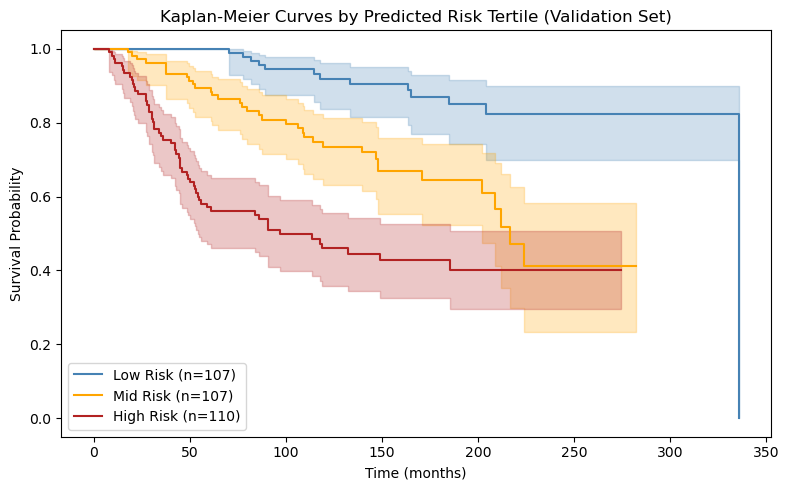

In [43]:
from lifelines import KaplanMeierFitter
from lifelines.statistics import multivariate_logrank_test
import matplotlib.pyplot as plt

model.eval()
with torch.no_grad():
    val_risk = model(X_val_tensor).numpy()

# Split into risk tertiles
tertiles = np.percentile(val_risk, [33, 66])
risk_group = np.digitize(val_risk, tertiles)  # 0=low, 1=mid, 2=high

# KM curves
kmf = KaplanMeierFitter()
fig, ax = plt.subplots(figsize=(8, 5))

for group, label, color in zip(
    [0, 1, 2],
    ["Low Risk", "Mid Risk", "High Risk"],
    ["steelblue", "orange", "firebrick"]
):
    mask = risk_group == group
    kmf.fit(time_val[mask], event_val[mask], label=f"{label} (n={mask.sum()})")
    kmf.plot_survival_function(ax=ax, color=color)

ax.set_title("Kaplan-Meier Curves by Predicted Risk Tertile (Validation Set)")
ax.set_xlabel("Time (months)")
ax.set_ylabel("Survival Probability")
ax.legend()
plt.tight_layout()
plt.show()

### Multivariate Log-Rank Test

The log-rank test formally tests whether the survival curves across predicted
risk groups are **statistically distinguishable** from one another, or whether
the observed differences could be due to random chance.

#### Null Hypothesis

$$
H_0: S_{\text{low}}(t) = S_{\text{mid}}(t) = S_{\text{high}}(t) \quad \forall\, t
$$

Under $H_0$, group membership has no effect on survival — deaths are distributed
proportionally to group size at every time point.

#### Setup

Let there be $K$ groups and $M$ distinct event times $t_1 < t_2 < \cdots < t_M$.

At each event time $t_j$, define:

- $d_{jk}$ = observed deaths in group $k$ at time $t_j$
- $n_{jk}$ = patients at risk in group $k$ just before $t_j$
- $d_j = \sum_k d_{jk}$ = total deaths at $t_j$
- $n_j = \sum_k n_{jk}$ = total patients at risk at $t_j$

#### Expected Deaths

Under $H_0$, the expected number of deaths in group $k$ at time $t_j$ is:

$$
e_{jk} = n_{jk} \times \frac{d_j}{n_j}
$$

That is, each group's share of the at-risk pool, multiplied by the total
number of deaths at that time point.

#### Observed Minus Expected

For each group $k$, accumulate the difference between observed and expected
deaths across all event times:

$$
U_k = \sum_{j=1}^{M} (d_{jk} - e_{jk})
$$

Collected into a vector of length $K-1$ (the last group is determined by the others
since $\sum_k U_k = 0$):

$$
\mathbf{U} = [U_1, U_2, \ldots, U_{K-1}]^\top
$$

#### Variance-Covariance Matrix

The variance of $U_k$ and covariance between groups $k$ and $l$ at each event
time come from the hypergeometric distribution. Summing across all event times:

$$
V_{kk} = \sum_{j=1}^{M} \frac{n_{jk}(n_j - n_{jk}) \cdot d_j(n_j - d_j)}{n_j^2(n_j - 1)}
$$

$$
V_{kl} = -\sum_{j=1}^{M} \frac{n_{jk} \cdot n_{jl} \cdot d_j(n_j - d_j)}{n_j^2(n_j - 1)}
\quad k \neq l
$$

This gives the full $(K-1) \times (K-1)$ variance-covariance matrix $\mathbf{V}$.

#### Test Statistic

The test statistic is the quadratic form:

$$
\chi^2 = \mathbf{U}^\top \mathbf{V}^{-1} \mathbf{U}
$$

Under $H_0$, this follows a **chi-squared distribution** with $K-1$ degrees
of freedom. For three risk groups ($K=3$), this gives $df = 2$.

#### P-value

$$
p = P(\chi^2_{K-1} \geq \chi^2_{\text{observed}})
$$

A small p-value indicates the observed survival differences are unlikely
under $H_0$, and we reject the hypothesis that all groups have equal survival.

#### Interpretation

| Result | Meaning |
|--------|---------|
| $p < 0.05$ | Survival curves are significantly different across groups |
| $p \geq 0.05$ | No significant difference detected |
| Large $\chi^2$, small $p$ | Strong evidence of risk stratification |
| $U_k \gg 0$ for low risk | Fewer deaths than expected — model correctly identified survivors |
| $U_k \ll 0$ for high risk | More deaths than expected — model correctly identified high risk patients |

#### Assumptions

- **Proportional hazards:** the relative difference between groups is consistent
  over time. If KM curves cross, this assumption is violated and the log-rank
  test loses statistical power
- **Independent censoring:** censoring is unrelated to the probability of the event
- **Large sample:** the $\chi^2$ approximation holds when event counts are not too small

> **Note:** The log-rank test confirms *statistical significance* of group separation
> but not *effect size*. A significant p-value with overlapping KM curves (common in
> large samples) may not be clinically meaningful. Always interpret alongside the
> KM plot and hazard ratios.

In [44]:
# Log-rank test
logrank = multivariate_logrank_test(time_val, risk_group, event_val)
print(f"Log-rank p-value: {logrank.p_value:.4f}")
logrank.print_summary()

Log-rank p-value: 0.0000


<lifelines.StatisticalResult: multivariate_logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 2
         test_name = multivariate_logrank_test

---
 test_statistic      p  -log2(p)
          58.39 <0.005     42.12

### Integrated Brier Score

#### Brier Score measures calibration: 
##### If the model predicts a patient has a 70% chance of surviving for 5 years, are ~70% of patients alive after 5 years? 

Brier Score evaluates the accuracy of the predicted survival function at a given time t. 

Represents average squared distances between observed survival status and predicted survival probability, and is always between 0 and 1 (0 is best possible value).

## Integrated Brier Score

The Brier Score at a single time point $t$ is:

$$
BS(t) = \frac{1}{n} \sum_{i=1}^{n} \left[
    \frac{\mathbf{1}(T_i \leq t,\, \delta_i = 1)}{\hat{G}(T_i)} \cdot \hat{S}_i(t)^2
    + \frac{\mathbf{1}(T_i > t)}{\hat{G}(t)} \cdot (1 - \hat{S}_i(t))^2
\right]
$$

Where:
- $\hat{S}_i(t)$ = predicted survival probability for patient $i$ at time $t$
- $\delta_i$ = event indicator (1 = died, 0 = censored)
- $\hat{G}(t)$ = Kaplan-Meier estimate of the censoring distribution (IPCW weight)

The **Integrated Brier Score** averages $BS(t)$ over a time range $[t_{min}, t_{max}]$:

$$
\text{IBS} = \frac{1}{t_{max} - t_{min}} \int_{t_{min}}^{t_{max}} BS(t)\, dt
$$

In our case, we stop evaluation after the 90th percentile because survival estimates become unreliable in the tail where few patients remain at risk

| IBS | Interpretation |
|-----|---------------|
| $< 0.15$ | Good calibration |
| $0.25$ | Uninformative (null model) |
| $> 0.25$ | Worse than no predictors |

In [71]:
def compute_ibs(train_risk, val_risk, surv_train, surv_val, time_val):
    """
    Compute the Integrated Brier Score for a survival model.

    Parameters:
        train_risk  : np.array — risk scores for training set
        val_risk    : np.array — risk scores for validation/test set
        surv_train  : structured array — training survival data (event, time)
        surv_val    : structured array — validation survival data (event, time)
        time_val    : np.array — survival times for validation/test set

    Returns:
        ibs : float — Integrated Brier Score
    """
    from sksurv.metrics import integrated_brier_score
    from sksurv.linear_model import CoxPHSurvivalAnalysis

    # Fit Cox reference on training risk scores to get baseline hazard
    cox_ref = CoxPHSurvivalAnalysis()
    cox_ref.fit(train_risk.reshape(-1, 1), surv_train)

    # Time grid within observed range
    times_ibs = np.linspace(
        time_val.min() + 1,
        np.percentile(time_val, 90),
        100
    )

    # Get survival probabilities for each patient at each time point
    surv_fns = cox_ref.predict_survival_function(val_risk.reshape(-1, 1))
    surv_probs = np.row_stack([fn(times_ibs) for fn in surv_fns])

    ibs = integrated_brier_score(surv_train, surv_val, surv_probs, times_ibs)
    return ibs

In [73]:
ibs = compute_ibs(train_risk, val_risk, surv_train, surv_val, time_val)
print(f"Integrated Brier Score: {ibs:.4f}")

Integrated Brier Score: 0.1457


/var/folders/lg/ycvb06q90x9cty7h1176t0200000gn/T/ipykernel_40440/495654230.py:31: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
  surv_probs = np.row_stack([fn(times_ibs) for fn in surv_fns])


### Time-Dependent AUC

The standard C-index summarizes discrimination across all time points in a
single number. Time-dependent AUC extends this by asking: **how well does
the model discriminate survival at each specific time point?** This is
particularly useful for identifying whether the model performs better at
predicting short-term versus long-term survival.

#### Defining Cases and Controls at Time $t$

At each time point $t$, patients are classified as:

- **Case:** patient $i$ experienced the event before $t$, i.e. $T_i \leq t$ and $\delta_i = 1$
- **Control:** patient $j$ survived past $t$, i.e. $T_j > t$

This classification changes at every time point — a patient who is a control
at $t = 12$ months may become a case at $t = 36$ months.

#### AUC at a Single Time Point

For a given time $t$, the AUC measures the probability that a randomly
selected case has a higher predicted risk score than a randomly selected
control:

$$
\text{AUC}(t) = P\left(\hat{r}_i > \hat{r}_j \mid T_i \leq t,\, \delta_i = 1,\, T_j > t\right)
$$

Where:
- $\hat{r}_i$ = predicted risk score for patient $i$
- $T_i$ = survival time for patient $i$
- $\delta_i$ = event indicator (1 = died, 0 = censored)

This is equivalent to the area under the ROC curve at time $t$, where the
ROC curve is constructed by varying the risk score threshold and plotting:

$$
\text{Sensitivity}(t) = P(\hat{r}_i > c \mid T_i \leq t,\,\delta_i = 1)
$$

$$
1 - \text{Specificity}(t) = P(\hat{r}_j > c \mid T_j > t)
$$

#### Handling Censoring with IPCW

Censored patients create ambiguity — a patient censored at $t = 24$ months
cannot be classified as a case or control at $t = 36$ months. This is
resolved using **Inverse Probability of Censoring Weighting (IPCW)**,
which reweights the contribution of each patient by the inverse probability
of not being censored:

$$
\text{AUC}(t) = \frac{
    \sum_{i:\,T_i \leq t,\,\delta_i=1}\, \sum_{j:\,T_j > t}
    \frac{\mathbf{1}(\hat{r}_i > \hat{r}_j)}{\hat{G}(T_i)\,\hat{G}(t)}
}{
    \sum_{i:\,T_i \leq t,\,\delta_i=1}\, \sum_{j:\,T_j > t}
    \frac{1}{\hat{G}(T_i)\,\hat{G}(t)}
}
$$

Where $\hat{G}(t)$ is the Kaplan-Meier estimate of the censoring distribution.
Patients who were likely to be censored receive higher weights, compensating
for their underrepresentation in the observed data.

#### Cumulative vs. Incident AUC

There are two common definitions of cases and controls:

$$
\text{Cumulative/Dynamic AUC: cases are } \{i : T_i \leq t,\, \delta_i = 1\}
$$

$$
\text{Incident/Dynamic AUC: cases are } \{i : T_i = t,\, \delta_i = 1\}
$$

**Cumulative AUC** (used by `sksurv`) accumulates all deaths up to $t$ as
cases — this is more stable because it uses more events per time point,
especially useful when events are rare at any single time.

#### Mean AUC

To summarize discrimination across all evaluated time points
$t_1, t_2, \ldots, t_M$, the mean AUC weights each time point by the
proportion of total events occurring up to that time:

$$
\overline{\text{AUC}} = \frac{1}{\hat{S}(t_{\min}) - \hat{S}(t_{\max})}
\int_{t_{\min}}^{t_{\max}} \text{AUC}(t)\, d\hat{F}(t)
$$

Where $\hat{F}(t) = 1 - \hat{S}(t)$ is the estimated marginal event
probability. In practice this integral is approximated over the discrete
set of evaluation time points.

#### Evaluated Time Points

In your model, AUC is evaluated at clinically meaningful time points:

| Time Point | Clinical Relevance |
|------------|--------------------|
| $t = 12$ months | 1-year survival |
| $t = 36$ months | 3-year survival |
| $t = 60$ months | 5-year survival |
| $t = 84$ months | 7-year survival |

#### Interpretation

| AUC$(t)$ | Meaning |
|----------|---------|
| $1.0$ | Perfect discrimination at time $t$ |
| $0.5$ | Random chance — no better than a coin flip |
| $< 0.5$ | Inverted predictions |
| $0.7 - 0.8$ | Good discrimination for clinical survival models |

A **declining AUC over time** is expected and normal — short-term risk
is generally easier to predict than long-term risk, as the influence of
measured clinical features weakens over longer follow-up periods.

#### Relationship to C-index

The C-index can be seen as a weighted average of $\text{AUC}(t)$ across
all event times, whereas time-dependent AUC resolves *when* discrimination
is strongest. A model with a moderate C-index may still have high AUC at
clinically critical time points such as 1-year or 5-year survival.

> **Note:** Time-dependent AUC measures *discrimination* — whether the model
> correctly ranks cases above controls at each time point. Like the C-index,
> it does not measure calibration. Always report alongside the Integrated
> Brier Score for a complete picture of model performance.


Time-dependent AUC:
  1-year AUC (12mo): 0.9581
  3-year AUC (36mo): 0.8623
  5-year AUC (60mo): 0.8619
  7-year AUC (84mo): 0.8091
  Mean AUC: 0.8591


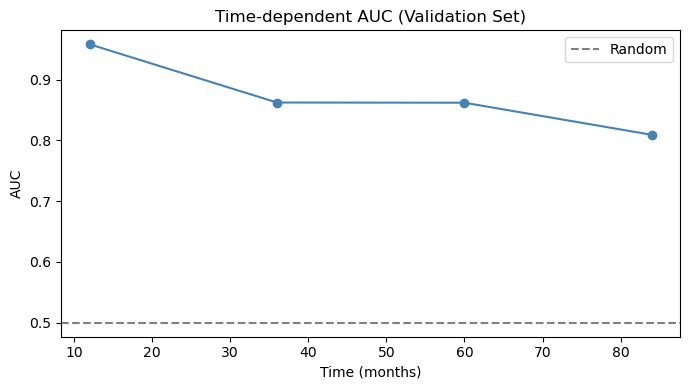

In [47]:
from sksurv.metrics import cumulative_dynamic_auc

# Clinically meaningful time points for breast cancer (months)
eval_times = [12, 36, 60, 84]  # 1, 3, 5, 7 years

# Filter to times within observed range
max_time = np.percentile(time_val, 90)
eval_times = [t for t in eval_times if t < max_time]

auc_scores, mean_auc = cumulative_dynamic_auc(
    surv_train, surv_val,
    val_risk,  # negative because higher risk = lower survival
    eval_times
)

print(f"\nTime-dependent AUC:")
for t, auc in zip(eval_times, auc_scores):
    years = t // 12
    print(f"  {years}-year AUC ({t}mo): {auc:.4f}")
print(f"  Mean AUC: {mean_auc:.4f}")

# Plot AUC over time
plt.figure(figsize=(7, 4))
plt.plot(eval_times, auc_scores, marker='o', color='steelblue')
plt.axhline(0.5, linestyle='--', color='gray', label='Random')
plt.xlabel("Time (months)")
plt.ylabel("AUC")
plt.title("Time-dependent AUC (Validation Set)")
plt.legend()
plt.tight_layout()
plt.show()

## Evaluation Metrics Wrapped Together

In [76]:
def evaluate_model(model, X_tensor, time_arr, event_arr, surv_train,
                   train_risk=None, label="Validation"):
    """
    Evaluate a survival model with C-index, time-dependent AUC, and IBS.

    Parameters:
        model       : torch.nn.Module — trained survival model
        X_tensor    : torch.Tensor — input features
        time_arr    : np.array — survival times
        event_arr   : np.array — event indicators (1=event, 0=censored)
        surv_train  : structured array — training survival data for IBS/AUC reference
        train_risk  : np.array, optional — training risk scores needed for IBS.
                      If None, IBS is skipped.
        label       : str — label for printed output (e.g. "Validation", "Test")

    Returns:
        dict with c_index, mean_auc, auc_by_time, and ibs (if computed)
    """
    model.eval()
    with torch.no_grad():
        risk = model(X_tensor).numpy()

    surv_arr = make_structured_array(event_arr, time_arr)

    # C-index
    ci = concordance_index(time_arr, -risk, event_arr)

    # Time-dependent AUC
    max_t = np.percentile(time_arr, 90)
    eval_times = [t for t in [12, 36, 60, 84] if t < max_t]
    auc_scores, mean_auc = cumulative_dynamic_auc(surv_train, surv_arr, risk, eval_times)

    # Integrated Brier Score (only if train_risk provided)
    ibs = None
    if train_risk is not None:
        ibs = compute_ibs(train_risk, risk, surv_train, surv_arr, time_arr)

    # Print results
    print(f"\n{'='*40}")
    print(f"  {label} Results")
    print(f"{'='*40}")
    print(f"  C-index:        {ci:.4f}")
    print(f"  Mean AUC:       {mean_auc:.4f}")
    for t, auc in zip(eval_times, auc_scores):
        print(f"    AUC @ {t:>3}mo:  {auc:.4f}")
    if ibs is not None:
        print(f"  Brier Score:    {ibs:.4f}  (< 0.15 good, 0.25 = uninformative)")

    results = {
        "c_index":      ci,
        "mean_auc":     mean_auc,
        "auc_by_time":  dict(zip(eval_times, auc_scores)),
        "ibs":          ibs
    }
    return results

# Validation and Test Results

In [79]:
# Compute train risk scores once after training
model.eval()
with torch.no_grad():
    train_risk = model(X_train_tensor).numpy()

# Evaluate with all metrics
val_results  = evaluate_model(model, X_val_tensor,  time_val,  event_val,
                               surv_train, train_risk=train_risk, label="Validation")

test_results = evaluate_model(model, X_test_tensor, time_test, event_test,
                               surv_train, train_risk=train_risk, label="Test")


  Validation Results
  C-index:        0.7561
  Mean AUC:       0.8591
    AUC @  12mo:  0.9581
    AUC @  36mo:  0.8623
    AUC @  60mo:  0.8619
    AUC @  84mo:  0.8091
  Brier Score:    0.1457  (< 0.15 good, 0.25 = uninformative)

  Test Results
  C-index:        0.7163
  Mean AUC:       0.7808
    AUC @  12mo:  0.8732
    AUC @  36mo:  0.7812
    AUC @  60mo:  0.7724
    AUC @  84mo:  0.7690
  Brier Score:    0.1459  (< 0.15 good, 0.25 = uninformative)


/var/folders/lg/ycvb06q90x9cty7h1176t0200000gn/T/ipykernel_40440/495654230.py:31: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
  surv_probs = np.row_stack([fn(times_ibs) for fn in surv_fns])
/var/folders/lg/ycvb06q90x9cty7h1176t0200000gn/T/ipykernel_40440/495654230.py:31: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
  surv_probs = np.row_stack([fn(times_ibs) for fn in surv_fns])


### Validation C-index: .7561 
### Test C-index: .7163
### Validation Mean AUC: .86
### Test Mean AUC: .78

# Expression Encoder
#### Next, we will add an expression encoder

In [61]:
# Load expression data
expression_data = pd.read_csv(here.here("data", "processed", "expression_data.csv"))

# Check structure
print(expression_data.shape)
print(expression_data.head(2))
print("Patient ID column:", expression_data.columns[0])  # confirm index column name

(1904, 489)
   brca1   brca2   palb2    pten    tp53     atm    cdh1   chek2     nbn  \
0 -1.399 -0.5738 -1.6217  1.4524  0.3504  1.1517  0.0348  0.1266 -0.8361   
1 -1.380  0.2777 -1.2154  0.5296 -0.0136 -0.2659  1.3594  0.7961  0.5419   

      nf1   stk11   bard1    mlh1    msh2    msh6    pms2   epcam  rad51c  \
0 -0.8578 -0.4294 -1.1201 -0.4844 -0.7483 -1.6660 -0.1250 -0.3721 -0.6508   
1 -2.6059  0.5120  0.4390  1.2266  0.7612  0.1821  1.0104  0.5600 -0.4018   

   rad51d  rad50     rb1    rbl1    rbl2   ccna1   ccnb1    cdk1   ccne1  \
0 -0.1278  1.733 -0.2770 -1.0673  0.0615  0.1034 -1.6635 -2.0649 -1.3388   
1 -0.2909  0.744 -1.7488  0.4602  0.7835 -0.2690 -0.2715  0.3895 -0.6273   

     cdk2  cdc25a   ccnd1    cdk4    cdk6   ccnd2  cdkn2a  cdkn2b     myc  \
0 -0.6208 -1.7309 -0.8059 -1.1037  0.0744  1.4313 -0.5785  1.2180  2.5602   
1  0.1813 -1.2643  1.1057  0.4108 -0.6040  0.0546  0.2754 -0.0952  0.7248   

   cdkn1a  cdkn1b    e2f1    e2f2    e2f3    e2f4    e2f5    e2f6 

In [62]:
# Check if rows are already in the same order as df
print(f"Expression rows: {expression_data.shape[0]}")
print(f"Clinical rows: {df.shape[0]}")

# Since there's no patient_id column, align by position using df's integer index
# First reset df index to confirm it's 0-based
print(df.index[:5])
print(expression_data.index[:5])

Expression rows: 1904
Clinical rows: 1904
RangeIndex(start=0, stop=5, step=1)
RangeIndex(start=0, stop=5, step=1)


#### Align Expression Data with Clinical Data

In [66]:
# Get positional locations of each split
train_pos = df.index.get_indexer(X_train.index)
val_pos   = df.index.get_indexer(X_val.index)
test_pos  = df.index.get_indexer(X_test.index)

# Split expression data by position
expr_train = expression_data.iloc[train_pos].values.astype(np.float32)
expr_val   = expression_data.iloc[val_pos].values.astype(np.float32)
expr_test  = expression_data.iloc[test_pos].values.astype(np.float32)

print(f"Train: {expr_train.shape}, Val: {expr_val.shape}, Test: {expr_test.shape}")

Train: (1294, 489), Val: (324, 489), Test: (286, 489)


### Normalize Expression Data
Microarray Expression data is already Z-scaled (mean expression of a gene = 0, std = 1). 

However, because we've split data into training, validation, and test sets, this consitutes data leakage, because the dataset was normalized/scaled based on the full dataset. 

Therefore, we will now re-normalize the expression data for each split

In [68]:
# Check if already well-normalized
print("Mean per gene (should be ~0):", expression_data.mean(axis=0).describe())
print("Std per gene (should be ~1):",  expression_data.std(axis=0).describe())

Mean per gene (should be ~0): count    4.890000e+02
mean    -4.188792e-09
std      7.362847e-07
min     -2.678571e-06
25%     -4.726891e-07
50%     -5.252101e-08
75%      5.252101e-07
max      2.258403e-06
dtype: float64
Std per gene (should be ~1): count    4.890000e+02
mean     1.000263e+00
std      6.548091e-07
min      1.000261e+00
25%      1.000262e+00
50%      1.000263e+00
75%      1.000263e+00
max      1.000265e+00
dtype: float64


In [ ]:
from sklearn.preprocessing import StandardScaler
# StandardScaler will standardize each gene to have mean=0 and std=1 based on training data stats, then apply same transformation to val/test

expr_scaler = StandardScaler()
expr_train = expr_scaler.fit_transform(expr_train)
expr_val   = expr_scaler.transform(expr_val)
expr_test  = expr_scaler.transform(expr_test)

expr_train_tensor = torch.tensor(expr_train, dtype=torch.float32)
expr_val_tensor   = torch.tensor(expr_val,   dtype=torch.float32)
expr_test_tensor  = torch.tensor(expr_test,  dtype=torch.float32)

print(f"Expression input dim: {expr_train_tensor.shape[1]}")

Expression input dim: 489


## Clinical + Expression Model

In [ ]:
import torch.nn as nn

class ClinicalExprSurvNet(nn.Module):
    def __init__(self, clin_dim, expr_dim):
        super().__init__()

        # Clinical encoder — same as before
        self.clin_enc = nn.Sequential(
            nn.Linear(clin_dim, 32),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Dropout(0.3)
        )

        # Expression encoder — bottleneck to compress high-dim input
        self.expr_enc = nn.Sequential(
            nn.Linear(expr_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(64, 32),
            nn.ReLU()
        )

        # Fusion head — takes concatenated embeddings
        self.head = nn.Sequential(
            nn.Linear(16 + 32, 32),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(32, 1)
        )

    def forward(self, x_clin, x_expr):
        z_clin = self.clin_enc(x_clin)
        z_expr = self.expr_enc(x_expr)
        z = torch.cat([z_clin, z_expr], dim=1)
        return self.head(z).squeeze(-1)